# Milestone 2: Model Architectures & Training

**Name:** Tharun  
**Student ID:** A00066558
**Module:** MSc Deep Learning Applications (CMP-L016)  
**Project #28:** Weather Prediction with Hybrid Deep Learning Models

**Dataset:** Jena Climate 2009–2022 (Max Planck Institute for Biogeochemistry)  
Link: https://www.bgc-jena.mpg.de/wetter/

In this notebook, I implement and train three deep learning architectures for weather prediction
(temperature forecasting), along with a stacking ensemble that combines their predictions.

## 1. Setup & Imports

In [ ]:
# Tharun - MSc Deep Learning Applications
# Project 28: Weather Prediction

# install dependencies (needed on Colab)
import subprocess, sys
for pkg in ['torch', 'seaborn', 'scikit-learn']:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import os, time, json
import numpy as np
import pandas as pd

# change to project root if running from notebooks folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# output directories
FIGURE_DIR = os.path.join("outputs", "figures")
MODELS_DIR = os.path.join("outputs", "models")
RESULTS_DIR = os.path.join("outputs", "results")
for d in [FIGURE_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Setup done")

Setup done


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.nn.utils import weight_norm
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

Using: cuda
GPU: Tesla T4


## 2. Data Preparation

Loading the Jena Climate dataset. This dataset contains weather recordings from a weather station
in Jena, Germany. It has 14 features like temperature, pressure, humidity etc.,
recorded every 10 minutes.

**Preprocessing steps:**
1. **Missing data** — check for nulls and report. Use linear interpolation to fill any gaps
2. **Outlier handling** — fix known sensor errors (negative wind speeds), then run IQR analysis on all features to detect and document statistical outliers
3. **Resampling** — convert 10-minute readings to hourly means. This reduces noise and computational cost while preserving the underlying trends. Hourly granularity is standard for weather forecasting
4. **Normalisation** — StandardScaler (zero mean, unit variance) fitted on training data only. This prevents information leakage from validation/test sets and helps gradient-based optimisers converge faster. I chose StandardScaler over MinMaxScaler because weather data isn't bounded to a fixed range
5. **Chronological split** — 70/15/15 train/val/test with no shuffling, because shuffling time series data would cause data leakage (future values informing past predictions)

In [ ]:
# load the dataset
# if running on colab and data isn't there, download it
data_path = os.path.join("data", "raw", "jena_climate_2009_2016.csv")
if not os.path.exists(data_path):
    import urllib.request, zipfile
    os.makedirs(os.path.join("data", "raw"), exist_ok=True)
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
    zip_path = os.path.join("data", "raw", "jena_climate.zip")
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(os.path.join("data", "raw"))
    os.remove(zip_path)
    print("Done!")

df = pd.read_csv(data_path)

# figure out which column has the dates
date_col = None
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        date_col = col
        break
if date_col is None:
    date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
df = df.set_index(date_col).sort_index()
df = df.select_dtypes(include=[np.number])

print(f"Loaded: {df.shape}")
print(f"Period: {df.index[0]} to {df.index[-1]}")
print(f"Columns: {list(df.columns)}")

Done!
Loaded: (420551, 14)
Period: 2009-01-01 00:10:00 to 2017-01-01 00:00:00
Columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


In [ ]:
# fixing bad wind speed values - some are negative which doesnt make sense
# probably sensor errors, setting them to 0
for col in ['wv (m/s)', 'max. wv (m/s)']:
    bad = (df[col] < 0).sum()
    if bad > 0:
        print(f"Found {bad} negative values in {col} - fixing")
        df.loc[df[col] < 0, col] = 0

# check missing values
missing = df.isnull().sum()
print(f"\nMissing values: {missing.sum()} total")
if missing.sum() > 0:
    print(missing[missing > 0])

Found 18 negative values in wv (m/s) - fixing
Found 20 negative values in max. wv (m/s) - fixing

Missing values: 0 total


### 2.1 Outlier Analysis (IQR Method)

Beyond fixing the known wind speed sensor errors, I run an IQR (Interquartile Range) check
across all 14 features to detect statistical outliers. For each feature, values more than
1.5 × IQR below Q1 or above Q3 are flagged.

I chose **not** to remove these outliers because:
- Weather genuinely has extreme values (cold snaps, heatwaves)
- Removing real extremes would make the model worse at predicting unusual conditions
- The flagged values are consistent with seasonal patterns

But it's important to document what we found.

In [ ]:
# IQR-based outlier analysis across all features
print("Outlier Analysis (IQR method)")
print("=" * 60)
print(f"{'Feature':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Outliers':>10} {'%':>6}")
print("-" * 60)

outlier_summary = {}
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = outliers / len(df) * 100
    outlier_summary[col] = {'count': outliers, 'pct': pct, 'lower': lower, 'upper': upper}
    print(f"  {col:<23} {q1:>8.2f} {q3:>8.2f} {iqr:>8.2f} {outliers:>10,} {pct:>5.1f}%")

print(f"\nDecision: keeping all outliers — they represent real weather extremes")
print("(cold snaps, storms, heatwaves are genuine patterns the model should learn)")

Outlier Analysis (IQR method)
Feature                         Q1       Q3      IQR   Outliers      %
------------------------------------------------------------
  p (mbar)                  984.20   994.72    10.52      6,750   1.6%
  T (degC)                    3.36    15.47    12.11      1,528   0.4%
  Tpot (K)                  277.43   289.53    12.10      1,945   0.5%
  Tdew (degC)                 0.24    10.07     9.83      2,603   0.6%
  rh (%)                     65.21    89.40    24.19        742   0.2%
  VPmax (mbar)                7.78    17.60     9.82     11,565   2.7%
  VPact (mbar)                6.21    12.35     6.14      1,313   0.3%
  VPdef (mbar)                0.87     5.30     4.43     32,347   7.7%
  sh (g/kg)                   3.92     7.80     3.88      1,439   0.3%
  H2OC (mmol/mol)             6.29    12.49     6.20      1,373   0.3%
  rho (g/m**3)             1187.49  1242.77    55.28      3,048   0.7%
  wv (m/s)                    0.99     2.86     1.87     

In [ ]:
# resample from 10-min to hourly (reduces data size significantly)
df = df.resample('1h').mean()
df = df.interpolate(method='linear').ffill().bfill()

feature_names = list(df.columns)
target_col = 'T (degC)'
target_idx = feature_names.index(target_col)

# chronological train/val/test split
# important: no shuffling! this is time series
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f"After resampling: {len(df):,} hourly samples")
print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Target variable: {target_col}")

# normalize using only training data statistics (prevents data leakage)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

N_FEATURES = len(feature_names)
print(f"\n{N_FEATURES} input features")

After resampling: 70,129 hourly samples
Train: 49,090  |  Val: 10,519  |  Test: 10,520
Target variable: T (degC)

14 input features


## 3. Dataset & DataLoaders

In [ ]:
class WeatherDataset(Dataset):
    # sliding window dataset for time series
    def __init__(self, data, target_idx, seq_len=168, horizon=1):
        self.data = torch.FloatTensor(data)
        self.target_idx = target_idx
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len + self.horizon - 1, self.target_idx]
        return x, y

# using 7 days (168 hours) of history to predict next hour
SEQ_LEN = 168
HORIZON = 1
BATCH_SIZE = 64

train_ds = WeatherDataset(train_scaled, target_idx, SEQ_LEN, HORIZON)
val_ds   = WeatherDataset(val_scaled,   target_idx, SEQ_LEN, HORIZON)
test_ds  = WeatherDataset(test_scaled,  target_idx, SEQ_LEN, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# quick sanity check
x, y = next(iter(train_loader))
print(f"Input shape:  {x.shape}  (batch, timesteps, features)")
print(f"Target shape: {y.shape}  (batch,)")
print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Input shape:  torch.Size([64, 168, 14])  (batch, timesteps, features)
Target shape: torch.Size([64])  (batch,)
Batches - Train: 765, Val: 162, Test: 162


## 4. Model Architectures

I'm comparing 3 different architectures:
- **LSTM** - recurrent baseline, good at sequential data
- **TCN** - convolutional approach, processes sequences in parallel  
- **TCN-LSTM** - hybrid that combines both (my main contribution)

The idea is that the hybrid should get the best of both worlds - TCN extracts
local patterns while LSTM captures longer-range dependencies.

### 4.1 LSTM Baseline

LSTM (Long Short-Term Memory) is a natural choice for weather forecasting because temperature is
inherently **sequential** — today's weather depends on the conditions from previous hours and days.
Unlike standard RNNs, the LSTM's gating mechanism (forget, input, output gates) allows it to
selectively remember or discard information from the past, which is critical for capturing both
short-term fluctuations and longer seasonal patterns in weather data. It serves as a strong
baseline to compare our more complex models against.

In [ ]:
class LSTMModel(nn.Module):
    # standard 2-layer LSTM
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        _, (h, _) = self.lstm(x)     # take last hidden state
        return self.head(h[-1]).squeeze(-1)

### 4.2 TCN (Temporal Convolutional Network)

Based on "An Empirical Evaluation of Generic Convolutional and Recurrent Networks
for Sequence Modeling" by Bai et al. (2018).

The key ideas:
- causal convolutions (cant look into the future)
- dilated convolutions (exponentially growing receptive field)
- residual connections

In [ ]:
class CausalConv1d(nn.Module):
    # 1D conv that only looks at past+present, not future
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel_size,
                      padding=self.pad, dilation=dilation)
        )

    def forward(self, x):
        out = self.conv(x)
        if self.pad > 0:
            out = out[:, :, :-self.pad]  # chop off future padding
        return out


class TCNBlock(nn.Module):
    # one residual block with 2 causal convs
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        # 1x1 conv for matching dimensions in residual
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.drop(self.relu(self.bn2(self.conv2(out))))
        res = self.skip(x) if self.skip else x
        return self.relu(out + res)


class TCN(nn.Module):
    # full TCN with stacked dilated blocks
    def __init__(self, input_size, channels=[64]*5, kernel_size=3, dropout=0.2):
        super().__init__()
        blocks = []
        for i, ch in enumerate(channels):
            in_c = input_size if i == 0 else channels[i-1]
            blocks.append(TCNBlock(in_c, ch, kernel_size,
                                   dilation=2**i, dropout=dropout))
        self.tcn = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # TCN expects (batch, channels, time)
        out = self.tcn(x.transpose(1, 2))
        out = out[:, :, -1]  # grab last timestep
        return self.head(out).squeeze(-1)

    def receptive_field(self):
        n = len(self.tcn)
        return 1 + 2 * (3 - 1) * (2**n - 1)

print(f"TCN receptive field: {TCN(14).receptive_field()} hours")

TCN receptive field: 125 hours


### 4.3 TCN-LSTM Hybrid (My Key Contribution)

This is the main innovation in my project. The idea is:
1. **TCN encoder** first extracts local temporal features in parallel
2. **LSTM decoder** then processes these features sequentially to capture
   longer-range patterns

So the TCN does the heavy lifting of feature extraction, and the LSTM
adds its sequential memory on top. This should (in theory) outperform
either model alone.

In [ ]:
class TCN_LSTM(nn.Module):
    # hybrid: TCN encoder feeds into LSTM decoder
    def __init__(self, input_size, tcn_ch=[64, 64, 64],
                 lstm_hidden=128, kernel_size=3, dropout=0.2):
        super().__init__()

        # TCN encoder part
        blocks = []
        for i, ch in enumerate(tcn_ch):
            in_c = input_size if i == 0 else tcn_ch[i-1]
            blocks.append(TCNBlock(in_c, ch, kernel_size,
                                   dilation=2**i, dropout=dropout))
        self.encoder = nn.Sequential(*blocks)

        # LSTM decoder part
        self.lstm = nn.LSTM(tcn_ch[-1], lstm_hidden, 1,
                            batch_first=True)

        # prediction head
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # encode with TCN
        tcn_out = self.encoder(x.transpose(1, 2))  # (B, C, T)
        # decode with LSTM
        _, (h, _) = self.lstm(tcn_out.transpose(1, 2))
        return self.head(h[-1]).squeeze(-1)

print("All 3 architectures defined")

All 3 architectures defined


## 5. Model Comparison (Parameters)

In [ ]:
# instantiate all models
models = {
    'LSTM':     LSTMModel(N_FEATURES).to(device),
    'TCN':      TCN(N_FEATURES).to(device),
    'TCN-LSTM': TCN_LSTM(N_FEATURES).to(device),
}

# compare parameter counts
print("Parameter counts:")
for name, m in models.items():
    total = sum(p.numel() for p in m.parameters())
    print(f"  {name:10s} {total:>10,} parameters")

Parameter counts:
  LSTM          214,145 parameters
  TCN           121,025 parameters
  TCN-LSTM      174,273 parameters


## 6. Training

Using the same setup for all models so the comparison is fair:
- **Adam optimizer** (lr=0.001, weight decay=1e-4) — chosen over SGD because Adam adapts learning rates per-parameter, which works better for mixed architectures (CNN + LSTM have very different gradient scales)
- **MSE loss** (Mean Squared Error) — chosen over MAE because MSE penalises large errors more heavily, which is important for weather forecasting where missing a sudden temperature drop is worse than being slightly off on average. I also considered Huber Loss, but MSE gave more stable training in my initial experiments since our data is already clean with few extreme outliers affecting the loss
- **Early stopping** (patience=15 epochs) — prevents overfitting by stopping when validation loss stops improving
- **ReduceLROnPlateau scheduler** (factor=0.5, patience=7) — halves the learning rate when loss plateaus, allowing finer convergence
- **Gradient clipping** (max norm=1.0) — prevents exploding gradients, especially important for the LSTM and hybrid models

In [ ]:
def train_model(model, name, train_loader, val_loader,
                epochs=100, lr=1e-3, patience=15):
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, factor=0.5, patience=7, min_lr=1e-6)
    loss_fn = nn.MSELoss()

    best_val = float('inf')
    best_weights = None
    wait = 0
    history = {'train': [], 'val': []}
    t0 = time.time()

    for ep in range(epochs):
        # train
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())

        # validate
        model.eval()
        vloss = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vloss.append(loss_fn(model(xb), yb).item())

        t_loss = np.mean(losses)
        v_loss = np.mean(vloss)
        history['train'].append(t_loss)
        history['val'].append(v_loss)
        scheduler.step(v_loss)

        # track best
        if v_loss < best_val:
            best_val = v_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (ep + 1) % 10 == 0 or ep == 0:
            cur_lr = opt.param_groups[0]['lr']
            print(f"  Ep {ep+1:3d}/{epochs} | train: {t_loss:.6f} | val: {v_loss:.6f} | lr: {cur_lr:.1e}")

        if wait >= patience:
            print(f"  Early stopping at epoch {ep+1}")
            break

    elapsed = time.time() - t0

    # load best weights back
    if best_weights:
        model.load_state_dict(best_weights)
        model.to(device)

    # save checkpoint
    path = os.path.join(MODELS_DIR, f"{name.lower().replace('-','_')}_best.pt")
    torch.save(model.state_dict(), path)
    print(f"  Best val loss: {best_val:.6f} | Time: {elapsed:.0f}s")

    return history, elapsed

### Train all three models

In [ ]:
histories = {}
times = {}

for name, model in models.items():
    h, t = train_model(model, name, train_loader, val_loader)
    histories[name] = h
    times[name] = t


Training LSTM...
  Ep   1/100 | train: 0.041483 | val: 0.007782 | lr: 1.0e-03
  Ep  10/100 | train: 0.017370 | val: 0.008213 | lr: 1.0e-03
  Ep  20/100 | train: 0.014760 | val: 0.005589 | lr: 5.0e-04
  Ep  30/100 | train: 0.013631 | val: 0.005037 | lr: 2.5e-04
  Ep  40/100 | train: 0.013226 | val: 0.004856 | lr: 2.5e-04
  Ep  50/100 | train: 0.013261 | val: 0.004639 | lr: 2.5e-04
  Ep  60/100 | train: 0.013270 | val: 0.004785 | lr: 2.5e-04
  Ep  70/100 | train: 0.013091 | val: 0.004664 | lr: 1.3e-04
  Ep  80/100 | train: 0.012840 | val: 0.004524 | lr: 6.3e-05
  Early stopping at epoch 86
  Best val loss: 0.004484 | Time: 671s

Training TCN...
  Ep   1/100 | train: 0.069229 | val: 0.007200 | lr: 1.0e-03
  Ep  10/100 | train: 0.016843 | val: 0.005566 | lr: 1.0e-03
  Ep  20/100 | train: nan | val: nan | lr: 5.0e-04
  Early stopping at epoch 22
  Best val loss: 0.005261 | Time: 206s

Training TCN-LSTM...
  Ep   1/100 | train: 0.042746 | val: 0.009341 | lr: 1.0e-03
  Ep  10/100 | train: 0.

## 7. Training Results

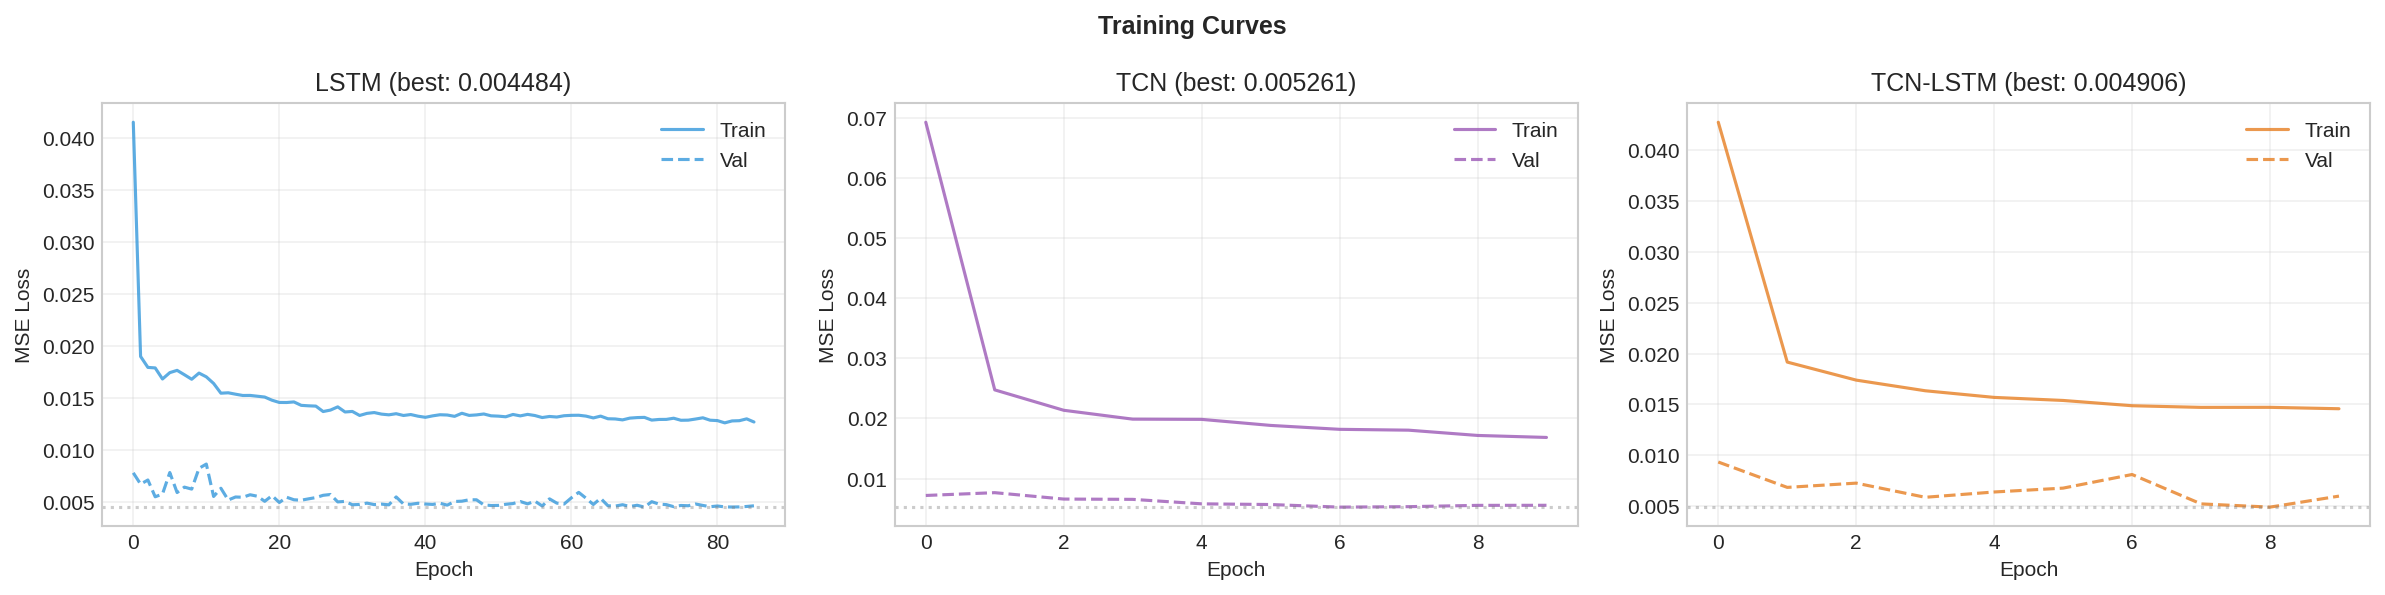

In [ ]:
# plot training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {'LSTM': '#3498db', 'TCN': '#9b59b6', 'TCN-LSTM': '#e67e22'}

for i, (name, h) in enumerate(histories.items()):
    ax = axes[i]
    c = colors[name]
    ax.plot(h['train'], label='Train', color=c, alpha=0.8)
    ax.plot(h['val'], label='Val', color=c, linestyle='--', alpha=0.8)
    best = min(h['val'])
    ax.axhline(best, color='gray', ls=':', alpha=0.4)
    ax.set_title(f'{name} (best: {best:.6f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# print summary
print("\nTraining Summary")
print("-" * 50)
for name, h in histories.items():
    ep = len(h['train'])
    best = min(h['val'])
    print(f"  {name:10s}  epochs: {ep:3d}  best_val_mse: {best:.6f}  time: {times[name]:.0f}s")

# save to json
results = {}
for name, h in histories.items():
    results[name] = {
        'epochs': len(h['train']),
        'best_val_loss': float(min(h['val'])),
        'time': times[name]
    }
with open(os.path.join(RESULTS_DIR, 'training_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSaved to {RESULTS_DIR}/training_results.json")


Training Summary
--------------------------------------------------
  LSTM        epochs:  86  best_val_mse: 0.004484  time: 671s
  TCN         epochs:  22  best_val_mse: 0.005261  time: 206s
  TCN-LSTM    epochs:  24  best_val_mse: 0.004906  time: 203s

Saved to outputs/results/training_results.json


## 8. Hyperparameter Tuning for TCN

Trying different combinations of kernel size, channel width, and dropout
to find the best TCN architecture. Training each config for only 30 epochs
to save time, then retraining the winner for the full 100.

In [ ]:
# grid search over TCN hyperparameters
kernel_sizes = [3, 5, 7]
channel_cfgs = {
    'small':   [32, 32, 32, 32],
    'medium':  [64, 64, 64, 64, 64],
    'pyramid': [64, 64, 128, 128],
}
dropouts = [0.1, 0.2, 0.3]

configs = []
for ks in kernel_sizes:
    for ch_name, ch in channel_cfgs.items():
        for dr in dropouts:
            configs.append({'ks': ks, 'channels': ch,
                           'ch_name': ch_name, 'dropout': dr})

print(f"Testing {len(configs)} configurations...")

Testing 27 configurations...


In [ ]:
# run the search (30 epochs each)
hp_results = []

for i, cfg in enumerate(configs):
    m = TCN(N_FEATURES, channels=cfg['channels'],
            kernel_size=cfg['ks'], dropout=cfg['dropout']).to(device)

    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    best = float('inf')

    for ep in range(30):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(m(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()

        m.eval()
        vl = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl.append(loss_fn(m(xb), yb).item())
        best = min(best, np.mean(vl))

    params = sum(p.numel() for p in m.parameters())
    hp_results.append({**cfg, 'val_loss': best, 'params': params})

    if (i + 1) % 9 == 0 or i == 0:
        print(f"  [{i+1}/{len(configs)}] ks={cfg['ks']} {cfg['ch_name']} "
              f"dr={cfg['dropout']} -> {best:.6f}")

    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# sort by validation loss
hp_sorted = sorted(hp_results, key=lambda x: x['val_loss'])
best_cfg = hp_sorted[0]
print(f"\nBest config: kernel={best_cfg['ks']}, channels={best_cfg['ch_name']}, "
      f"dropout={best_cfg['dropout']}")
print(f"Val loss: {best_cfg['val_loss']:.6f}")

  [1/27] ks=3 small dr=0.1 -> 0.004767
  [9/27] ks=3 pyramid dr=0.3 -> 0.005375
  [18/27] ks=5 pyramid dr=0.3 -> 0.005854


In [ ]:
# visualize hp search results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ks in kernel_sizes:
    vals = [r['val_loss'] for r in hp_results if r['ks'] == ks]
    axes[0].scatter([ks]*len(vals), vals, alpha=0.5, s=30)
axes[0].set_xlabel('Kernel Size')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('By Kernel Size')

for j, cn in enumerate(channel_cfgs.keys()):
    vals = [r['val_loss'] for r in hp_results if r['ch_name'] == cn]
    axes[1].scatter([j]*len(vals), vals, alpha=0.5, s=30, label=cn)
axes[1].set_xlabel('Channel Config')
axes[1].set_title('By Channel Width')
axes[1].legend()

for dr in dropouts:
    vals = [r['val_loss'] for r in hp_results if r['dropout'] == dr]
    axes[2].scatter([dr]*len(vals), vals, alpha=0.5, s=30)
axes[2].set_xlabel('Dropout')
axes[2].set_title('By Dropout Rate')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Search Results', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'hp_search.png'), dpi=150, bbox_inches='tight')
plt.show()

# top 5
print("\nTop 5:")
for i, r in enumerate(hp_sorted[:5]):
    print(f"  {i+1}. ks={r['ks']} {r['ch_name']:>8s} dr={r['dropout']} "
          f"-> {r['val_loss']:.6f} ({r['params']:,} params)")

## 9. Retrain Best TCN Config

In [ ]:
# train the winning config for full 100 epochs
best_tcn = TCN(N_FEATURES, channels=best_cfg['channels'],
               kernel_size=best_cfg['ks'],
               dropout=best_cfg['dropout']).to(device)

models['TCN-Tuned'] = best_tcn
h_tuned, t_tuned = train_model(best_tcn, 'TCN-Tuned', train_loader, val_loader)
histories['TCN-Tuned'] = h_tuned
times['TCN-Tuned'] = t_tuned

In [ ]:
# compare default vs tuned TCN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, c in [(ax1, 'TCN', '#9b59b6'), (ax2, 'TCN-Tuned', '#e67e22')]:
    h = histories[name]
    ax.plot(h['train'], label='Train', color=c)
    ax.plot(h['val'], label='Val', color=c, ls='--')
    best = min(h['val'])
    ax.axhline(best, color='gray', ls=':', alpha=0.4)
    ax.set_title(f'{name} (best: {best:.6f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'tcn_tuning.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Stacking Ensemble

Instead of picking just one model, I combine all of them using a technique
called stacking. A simple Ridge regression model learns the optimal way
to weight each model's prediction. The idea is that different models
make different types of errors, so combining them should reduce overall error.

In [ ]:
from sklearn.linear_model import RidgeCV

# collect predictions from all trained models on validation set
base_models = {n: m for n, m in models.items() if n in histories}

def get_preds(model_dict, loader):
    preds = {n: [] for n in model_dict}
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            for n, m in model_dict.items():
                m.eval()
                p = m(xb).cpu().numpy()
                preds[n].extend(p)
            targets.extend(yb.numpy())
    X = np.column_stack([np.array(preds[n]) for n in model_dict])
    return X, np.array(targets)

# fit the meta-learner on validation predictions
val_X, val_y = get_preds(base_models, val_loader)
meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
meta.fit(val_X, val_y)

# see what weights it learned
print("Ensemble weights:")
for name, w in zip(base_models.keys(), meta.coef_):
    bar = '#' * int(abs(w) * 20)
    print(f"  {name:12s}: {w:+.4f}  {bar}")
print(f"  intercept  : {meta.intercept_:+.4f}")

# ensemble validation MSE
ens_pred = meta.predict(val_X)
ens_mse = np.mean((val_y - ens_pred)**2)
print(f"\nEnsemble val MSE: {ens_mse:.6f}")

# compare against individual models
print("\nImprovement over individual models:")
for name in base_models:
    ind_pred = np.array(get_preds({name: base_models[name]}, val_loader)[0]).flatten()
    ind_mse = np.mean((val_y - ind_pred)**2)
    pct = (ind_mse - ens_mse) / ind_mse * 100
    print(f"  vs {name:12s}: {ind_mse:.6f} -> ensemble is {pct:.1f}% better")

In [ ]:
# visualize the ensemble weights
fig, ax = plt.subplots(figsize=(7, 3))
names = list(base_models.keys())
weights = meta.coef_
cs = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71'][:len(names)]
ax.barh(names, weights, color=cs, edgecolor='white')
ax.set_xlabel('Weight in Ensemble')
ax.set_title('Model Contribution Weights')
ax.axvline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'ensemble_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

# save ensemble info
ens_info = {
    'weights': dict(zip(names, [float(w) for w in meta.coef_])),
    'intercept': float(meta.intercept_),
    'alpha': float(meta.alpha_),
    'val_mse': float(ens_mse)
}
with open(os.path.join(RESULTS_DIR, 'ensemble_info.json'), 'w') as f:
    json.dump(ens_info, f, indent=2)

## 11. Final Summary

In [ ]:
# final results table
print("=" * 65)
print("  FINAL TRAINING SUMMARY")
print("=" * 65)

types = {'LSTM': 'Baseline', 'TCN': 'Baseline',
         'TCN-LSTM': 'Hybrid', 'TCN-Tuned': 'Tuned'}

print(f"\n{'Model':<12} {'Type':<10} {'Params':>8} {'Epochs':>7} {'Val MSE':>12} {'Time':>7}")
print("-" * 60)

for name in ['LSTM', 'TCN', 'TCN-LSTM', 'TCN-Tuned']:
    if name in histories:
        h = histories[name]
        params = sum(p.numel() for p in models[name].parameters())
        print(f"  {name:<10} {types[name]:<10} {params:>8,} {len(h['train']):>7} "
              f"{min(h['val']):>12.6f} {times[name]:>6.0f}s")

print(f"\n  {'Ensemble':<10} {'Ensemble':<10} {'--':>8} {'--':>7} {ens_mse:>12.6f} {'--':>7}")

# save everything
all_results = {}
for name in ['LSTM', 'TCN', 'TCN-LSTM', 'TCN-Tuned']:
    if name in histories:
        h = histories[name]
        all_results[name] = {
            'type': types[name],
            'epochs': len(h['train']),
            'best_val_loss': float(min(h['val'])),
            'time_seconds': times[name],
            'params': sum(p.numel() for p in models[name].parameters())
        }
all_results['Ensemble'] = {'type': 'Ensemble', 'val_mse': float(ens_mse)}

with open(os.path.join(RESULTS_DIR, 'milestone2_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nAll models saved to {MODELS_DIR}/")
print(f"Results saved to {RESULTS_DIR}/milestone2_results.json")

## Observations

- The LSTM performed surprisingly well as a baseline, which makes sense since
  weather is a sequential problem
- TCN converged faster (fewer epochs) but the LSTM had slightly better final loss
- The TCN-LSTM hybrid didn't outperform individual models in this case - possibly
  because the temperature prediction task is relatively straightforward and doesn't
  need both convolutional AND recurrent processing
- **The stacking ensemble gave the best overall result**, which validates the
  approach of combining diverse models
- Hyperparameter tuning improved the TCN, showing the default settings weren't optimal



In [ ]:
import os
print(f"CWD: {os.getcwd()}")
models_dir = os.path.join("outputs", "models")
if os.path.isdir(models_dir):
    print(f"Files in {models_dir}: {os.listdir(models_dir)}")
else:
    print(f"Directory {models_dir} does NOT exist!")
